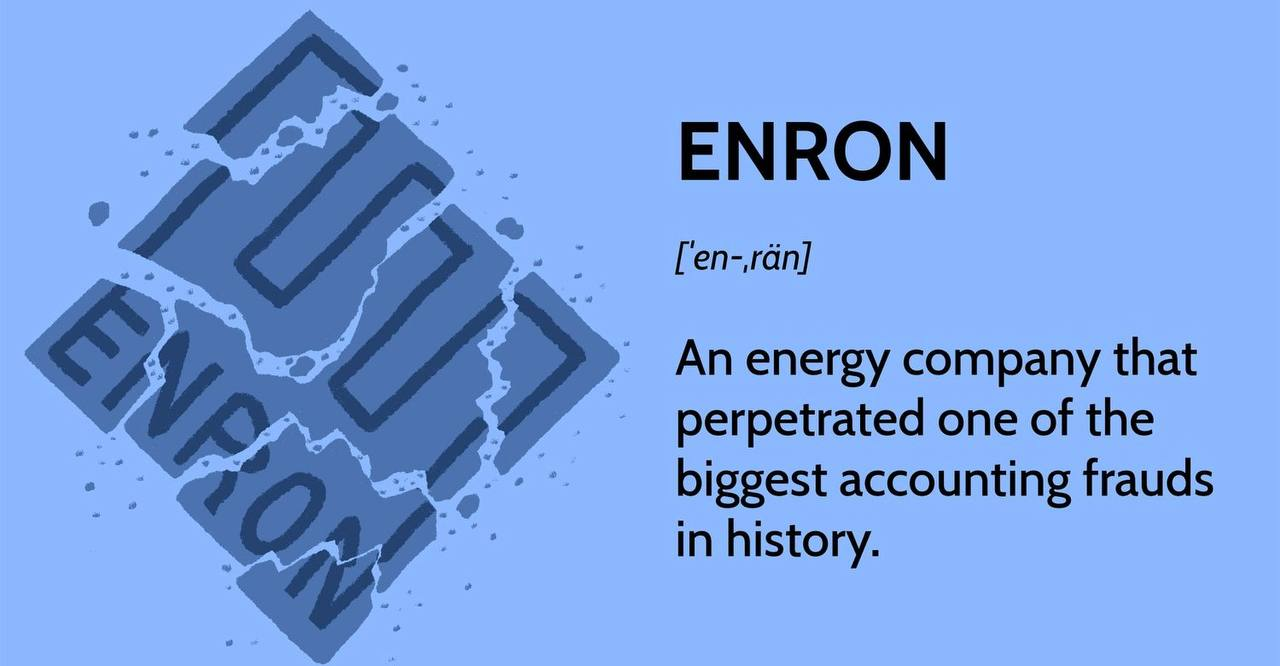

## Структура работы
#### 1. Историческая справка о датасете (markdown)
#### 2. Импорт данных и библиотек
#### 3. EDA (исследовательский анализ данных)
#### 4. Feature engineering (извлечение признаков)
#### 5. Подготовка пайплайна и моделей
#### 6. Обучение, оценка, визуализация

## Историческая справка

### Датасет "Enron Email Dataset" появился в результате расследования крупнейшего корпоративного скандала в истории США — краха энергетической корпорации Enron Corporation в декабре 2001 года.

### Enron была одной из крупнейших энергетических компаний США.
##### --В 2001 году она обанкротилась из-за масштабных бухгалтерских махинаций и финансовых махинаций (энроновский скандал).
##### Это привело к уголовному расследованию.

#### --Изъятие электронных писем:
##### В ходе расследования Министерство юстиции США изъяло большое количество внутренних электронных писем сотрудников компании.
##### В основном переписка велась между руководителями, менеджерами и другими сотрудниками.

#### --Публикация данных (2003–2004):
##### В 2003 году Федеральная энергетическая регуляторная комиссия (FERC) опубликовала часть этой переписки в публичном доступе в рамках расследования.
##### В 2004 году Калифорнийский университет в Беркли и другие исследователи подготовили датасет из этих писем в более структурированном и пригодном для анализа виде.

## Что содержит датасет:
#### Более 500 000 писем.
#### Около 150 пользователей (в основном старшие сотрудники Enron).
#### Формат: папки «inbox», «sent», «deleted items» и другие (в оригинальном датасете)
#### Формат хранения: часто .mbox или структура папок.

### Зачем используется:
#### Enron dataset — один из немногих реальных и публичных больших корпоративных email-корпусов. Он стал золотым стандартом для:

#### --задач обработки естественного языка (NLP);

#### --анализов соцсетей, потоков коммуникаций;

#### --машинного обучения, в том числе для определения спама, тональности и пр.;

#### --изучения организационного поведения и коммуникации в компаниях.

## Цель:
### определить, является ли письмо спамом (spam = 1) или обычным (ham = 0), используя машинное обучение.

## Переменные:
### text
### spam

## Import libraries and EDA

In [118]:
import numpy as np # массивы, математика  
import pandas as pd # таблицы, данные  
import matplotlib.pyplot as plt  # графики  
import seaborn as sns  # графики  
import string  # символы, пунктуация  
import re  # регулярные выражения  
import time # замер времени  
import timeit  # точный таймер  
from collections import Counter  # подсчёт частот  
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # стоп-слова  
from sklearn.model_selection import train_test_split # разбиение выборки  
from sklearn.pipeline import Pipeline 
from sklearn.feature_extraction.text import TfidfVectorizer # текст -вектор  
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier   
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression              
from sklearn.naive_bayes import MultinomialNB                    
from sklearn.metrics import (                        
    accuracy_score,  
    precision_score, 
    recall_score,           
    f1_score,                
    roc_auc_score,          
    confusion_matrix,        
    ConfusionMatrixDisplay,  # визуализация матрицы  
    classification_report  
)

In [119]:
df = pd.read_csv('../emails.csv')
df.shape

(5728, 2)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [121]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [122]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [123]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [124]:
ham = df[df['spam']==0]
spam =df[df['spam']==1]

In [125]:
spam

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1
1364,Subject: would you like a $ 250 gas card ? do...,1
1365,"Subject: immediate reply needed dear sir , i...",1
1366,Subject: wanna see me get fisted ? fist bang...,1


In [126]:
ham

,text,spam
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0
1369,Subject: sacramento weather station fyi - - ...,0
1370,Subject: from the enron india newsdesk - jan 1...,0
1371,Subject: re : powerisk 2001 - your invitation ...,0
1372,Subject: re : resco database and customer capt...,0
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


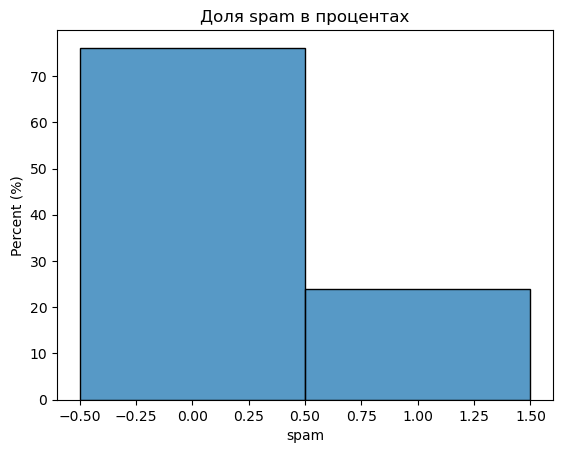

In [127]:
sns.histplot(x='spam', data=df, stat='percent',discrete=True)
plt.ylabel('Percent (%)')
plt.title('Доля spam в процентах')
plt.show()

### Видим что датасет несбалансирован, ham(около 75%)больше, чем spam(около 25%)

In [128]:
df['text_length_words'] = df['text'].apply(lambda x: len(x.split()))

In [129]:
df['text_length_words'].describe()

count    5728.000000
mean      326.848638
std       418.777435
min         2.000000
25%       101.000000
50%       210.000000
75%       401.000000
max      8477.000000
Name: text_length_words, dtype: float64

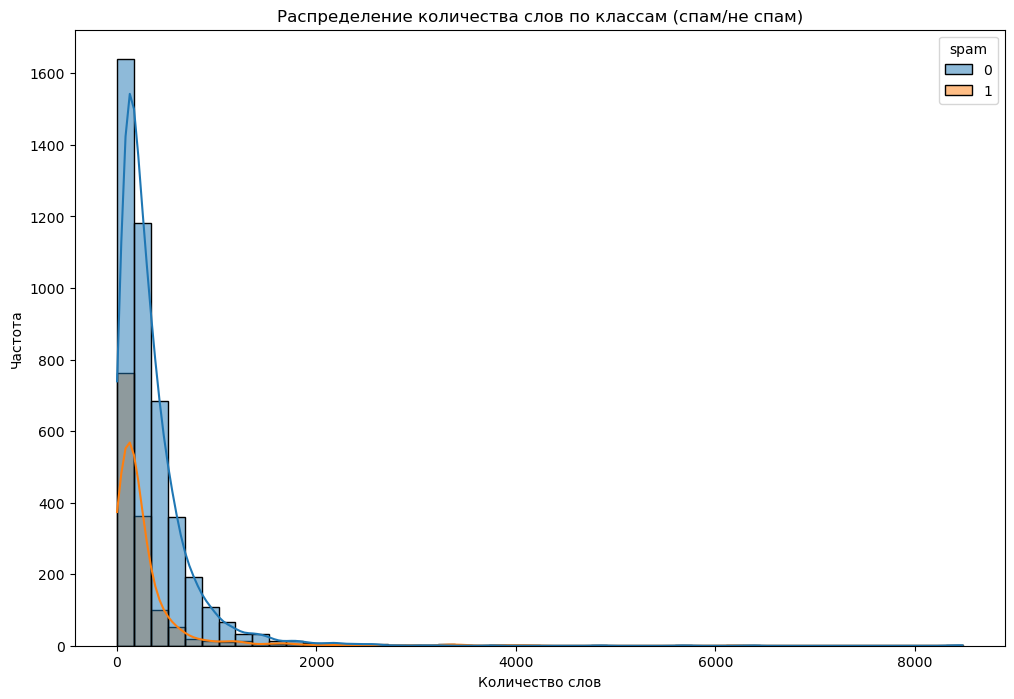

In [130]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='text_length_words', hue='spam', bins=50, kde=True)
plt.title("Распределение количества слов по классам (спам/не спам)")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

## Выводы с графика:  Только по количеству слов трудно чётко отличить спам от не-спама.
#### 1. Большинство писем короткие — от 0 до ~500 слов.
#### 2. Спам и хэм распределены похоже, но:
#### Спам чуть чаще попадается с очень короткими письмами (в районе 0–100 слов).
#### Длинные письма (> 1000 слов) — редкость для обеих категорий.

In [131]:
# самое длинное сообщение 8477 слов
longest_msg = df.loc[df['text_length_words'].idxmax()]
print(longest_msg['text']) 
print("Длина:", longest_msg['text_length_words'])

Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on 04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 , http : / / www . businessstandard . com / today / economy 4 . asp ? menu = 3  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 / topl . h

In [132]:
top_long = df.sort_values(by='text_length_words', ascending=False)

In [133]:
top_long

,text,spam,text_length_words
2650,Subject: from the enron india newsdesk - april...,0,8477
1380,Subject: from the enron india newsdesk - april...,0,8364
2338,Subject: from the enron india newsdesk - april...,0,6348
536,Subject: make thousands just sending emails . ...,1,6129
2560,Subject: from the enron india newsdesk - may 5...,0,5689
...,...,...,...
5405,Subject: proposal - kevin kindall,0,5
568,Subject: . jif .,1,4
2567,Subject: this hurricane elana,0,4
2263,Subject: elena chilkina hi,0,4


In [134]:
top_long20 = df[df['text_length_words'] >= 8000]

In [135]:
for i, row in top_long20.sort_values(by='text_length_words').iterrows():
    print(f"\n Сообщение {i} (Длина: {row['text_length_words']}) \n")
    print(row['text'])


- Сообщение 1380 (Длина: 8364) -

Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on  04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 ,  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 / topl . html  foreign lenders slam brakes on disbu

In [136]:
shortest_msgs = df.sort_values(by='text_length_words', ascending=True)
shortest_msgs

,text,spam,text_length_words
1991,Subject: fyi,0,2
2263,Subject: elena chilkina hi,0,4
568,Subject: . jif .,1,4
2567,Subject: this hurricane elana,0,4
5405,Subject: proposal - kevin kindall,0,5
...,...,...,...
2560,Subject: from the enron india newsdesk - may 5...,0,5689
536,Subject: make thousands just sending emails . ...,1,6129
2338,Subject: from the enron india newsdesk - april...,0,6348
1380,Subject: from the enron india newsdesk - april...,0,8364


In [137]:
short_msgs_top20 = df[df['text_length_words'] <= 20]

In [138]:
for i, row in short_msgs_top20.sort_values(by='text_length_words').iterrows():
    print(f"\nСообщение {i} (Длина: {row['text_length_words']})\n")
    print(row['text'])


- Сообщение 1991 (Длина: 2) -

Subject: fyi 

- Сообщение 568 (Длина: 4) -

Subject: . jif  . 

- Сообщение 2263 (Длина: 4) -

Subject: elena chilkina  hi

- Сообщение 2567 (Длина: 4) -

Subject: this  hurricane elana 

- Сообщение 5405 (Длина: 5) -

Subject: proposal  - kevin kindall

- Сообщение 2009 (Длина: 6) -

Subject: congratulations - well deserved . 

- Сообщение 3354 (Длина: 6) -

Subject: itinerary  phelim ,  fyi  vince

- Сообщение 631 (Длина: 6) -

Subject: discreet penis enlargement 4623  4623

- Сообщение 3806 (Длина: 7) -

Subject: congratulations on your promotion . lou 

- Сообщение 3035 (Длина: 7) -

Subject: re : research allocation  thank you

- Сообщение 4398 (Длина: 7) -

Subject: re : rankings  thank you .

- Сообщение 2841 (Длина: 7) -

Subject: your approval is requested  thank you

- Сообщение 4320 (Длина: 7) -

Subject: password  login kkindal  password marketcredit !

- Сообщение 4158 (Длина: 9) -

Subject: re : requests for help  thanks vince .

- Сообщен

## Извлекаем дату из первых строк сообщения

## Почему есть письма за 2002 год, если Enron закрыли в 2001?
Официально компания Enron объявила о банкротстве в декабре 2001 года, но: Полный процесс ликвидации и работы по делам компании продолжался еще несколько лет (вплоть до 2004–2007 годов). Некоторые подразделения продолжали работать для завершения контрактов, юридических процессов, распродажи активов, аудитов и расследований. Некоторые внутренние сервисы Enron продолжали функционировать, пока шло банкротство.

# Подтверждение из официальных источников:
### "The Enron Corpus consists of 500,000 emails generated by about 150 Enron employees. The data was collected during the investigation into Enron's collapse and includes emails from 1998 until early 2002." — источник: Carnegie Mellon University (создатель датасета)

### Попытка разделить сообщения на отправленные и полученные, затем узнать в каких больше спама

### не получилось отсортировать письма на 'полученные' и 'отправленные'

In [139]:
df

,text,spam,text_length_words
0,Subject: naturally irresistible your corporate...,1,324
1,Subject: the stock trading gunslinger fanny i...,1,89
2,Subject: unbelievable new homes made easy im ...,1,87
3,Subject: 4 color printing special request add...,1,98
4,"Subject: do not have money , get software cds ...",1,52
...,...,...,...
5723,Subject: re : research and development charges...,0,297
5724,"Subject: re : receipts from visit jim , than...",0,244
5725,Subject: re : enron case study update wow ! a...,0,515
5726,"Subject: re : interest david , please , call...",0,276


## Feature engineering and  text cleaning

In [140]:
# Функция для извлечения признаков
def extract_features(text):
    text = str(text)
    email_length = len(text)
    num_words = len(text.split())
    uppercase_ratio = sum(1 for c in text if c.isupper()) / (len(text) + 1e-5) #доля заглавных букв
    num_exclamations = text.count('!')
    spammy_words = ['free','win','money','urgent','discount','offer','click','buy','cash','congratulations']
    has_spammy_words = int(any(w in text.lower() for w in spammy_words))
    
    return pd.Series({
        'email_length': email_length,
        'num_words': num_words,
        'uppercase_ratio': uppercase_ratio,
        'num_exclamations': num_exclamations,
        'has_spammy_words': has_spammy_words
    })

# Применяем функцию к каждому письму — получаем новые столбцы
feat_df = df['text'].apply(extract_features)
df = pd.concat([df, feat_df], axis=1)

# Собираем весь текст в один большой 
all_text = " ".join(df['text'].astype(str))
# приводим к нижнему регистру и удаляем пунктуацию
all_text = all_text.lower()
all_text = all_text.translate(str.maketrans('', '', string.punctuation))

# Считаем сырые частоты
words = all_text.split()
word_freq = Counter(words)
print("Топ-20 самых частых слов (включая стоп-слова):")
print(word_freq.most_common(20))

# Отфильтруем стоп-слова и пересчитаем
filtered_words = [w for w in words if w not in ENGLISH_STOP_WORDS]
filtered_freq = Counter(filtered_words)
print("\nТоп-20 самых частотных слов (без стоп-слов):")
print(filtered_freq.most_common(20))

Топ-20 самых частых слов (включая стоп-слова):
[('the', 50110), ('to', 41736), ('and', 27478), ('of', 23757), ('a', 19945), ('you', 19154), ('in', 17975), ('i', 17421), ('for', 16696), ('enron', 13382), ('on', 12719), ('is', 12595), ('ect', 11418), ('subject', 10179), ('this', 10031), ('that', 9291), ('your', 9274), ('be', 9262), ('with', 8853), ('we', 8688)]

Топ-20 самых частотных слов (без стоп-слов):
[('enron', 13382), ('ect', 11418), ('subject', 10179), ('vince', 8532), ('s', 6506), ('hou', 5577), ('com', 5442), ('2000', 4967), ('kaminski', 4770), ('cc', 3896), ('j', 3764), ('1', 3442), ('pm', 3286), ('2001', 3089), ('2', 2936), ('time', 2733), ('research', 2733), ('10', 2618), ('thanks', 2585), ('know', 2545)]


In [141]:
df.isnull().sum()

text                 0
spam                 0
text_length_words    0
email_length         0
num_words            0
uppercase_ratio      0
num_exclamations     0
has_spammy_words     0
dtype: int64

In [142]:
df.head()

,text,spam,text_length_words,email_length,num_words,uppercase_ratio,num_exclamations,has_spammy_words
0,Subject: naturally irresistible your corporate...,1,324,1484.0,324.0,0.000674,0.0,0.0
1,Subject: the stock trading gunslinger fanny i...,1,89,598.0,89.0,0.001672,0.0,0.0
2,Subject: unbelievable new homes made easy im ...,1,87,448.0,87.0,0.002232,0.0,1.0
3,Subject: 4 color printing special request add...,1,98,500.0,98.0,0.002000,2.0,1.0
4,"Subject: do not have money , get software cds ...",1,52,235.0,52.0,0.004255,1.0,1.0


## Pipeline

In [143]:
X = df['text'].astype(str)
y = df['spam'].astype(int)

print(len(X), len(y))  

5728 5728


In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

In [145]:
svm_pipe = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=3,  max_df=0.95, max_features=5000)),
    ('svc', SVC(kernel='linear', probability=True, class_weight='balanced', random_state=0))
])

rf_pipe = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2), min_df=5,  max_df=0.9)),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=None, min_samples_split=2, max_features='sqrt', random_state=0))
])

xgb_pipe = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2), min_df=3, max_df=0.95)),
    ('xgb', XGBClassifier(eval_metric='logloss', scale_pos_weight=3, learning_rate=0.1, random_state=0))
])

logreg_pipe = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=3, max_df=0.95, max_features=5000)),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=0))
])

nb_pipe = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2), min_df=3, max_df=0.95,)),
    ('nb', MultinomialNB())
])

pipelines = {
    'SVM': svm_pipe,
    'Random Forest': rf_pipe,
    'XGBoost': xgb_pipe,
    'Logistic Reg.': logreg_pipe,
    'Multinomial NB': nb_pipe
}

In [146]:
records = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    for tag, (X_split, y_true) in [
        ('Train', (X_train, y_train)),
        ('Test', (X_test, y_test))
    ]:
        y_pred = pipe.predict(X_split)
        rec = {
            'Model': name,
            'Dataset': tag,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred)
        }
        estimator = pipe.named_steps[list(pipe.named_steps)[-1]]
        if hasattr(estimator, 'predict_proba'):
            y_proba = pipe.predict_proba(X_split)[:, 1]
            rec['ROC-AUC'] = roc_auc_score(y_true, y_proba)
        else:
            rec['ROC-AUC'] = np.nan
        records.append(rec)

df_metrics = pd.DataFrame(records)

## Result's visualisation

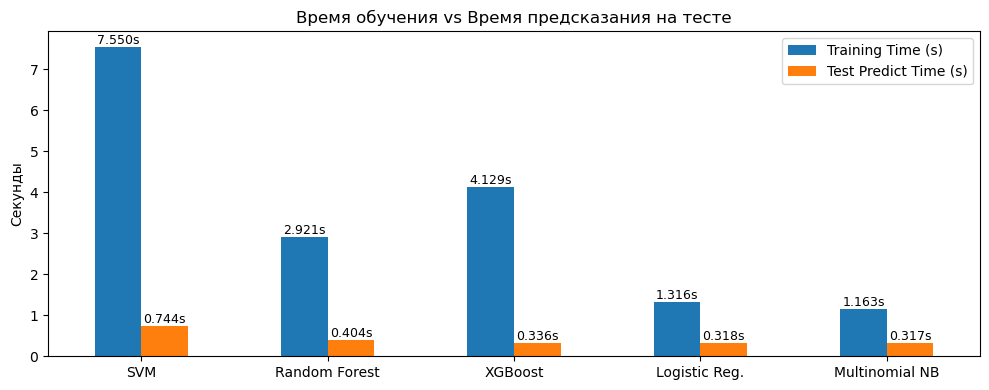

In [147]:
train_times = {}
test_pred_times = {}

for name, pipe in pipelines.items():
    # Измеряем время обучения
    train_time = timeit.timeit(lambda: pipe.fit(X_train, y_train), number=1)
    train_times[name] = train_time

    # Измеряем время предсказания
    predict_fn = lambda: pipe.predict(X_test)
    predict_time = timeit.timeit(predict_fn, number=1)
    test_pred_times[name] = predict_time
times_df = pd.DataFrame({
    'Training Time (s)': train_times,
    'Test Predict Time (s)': test_pred_times})

# Визуализация
ax = times_df.plot(kind='bar', figsize=(10, 4))
plt.title('Время обучения vs Время предсказания на тесте')
plt.ylabel('Секунды')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}s',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

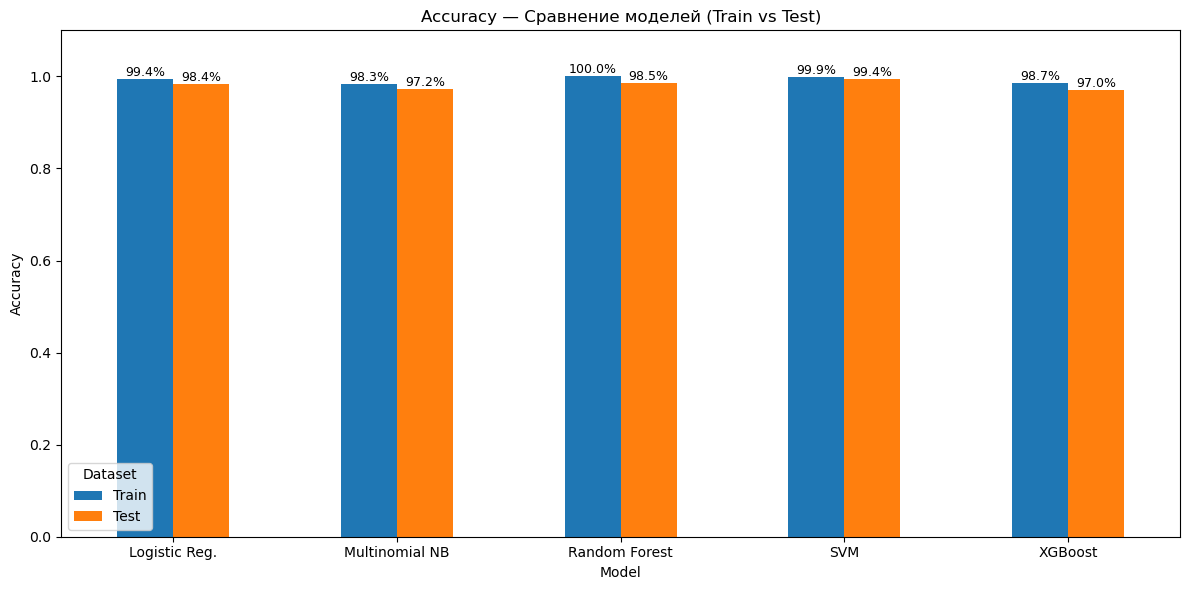

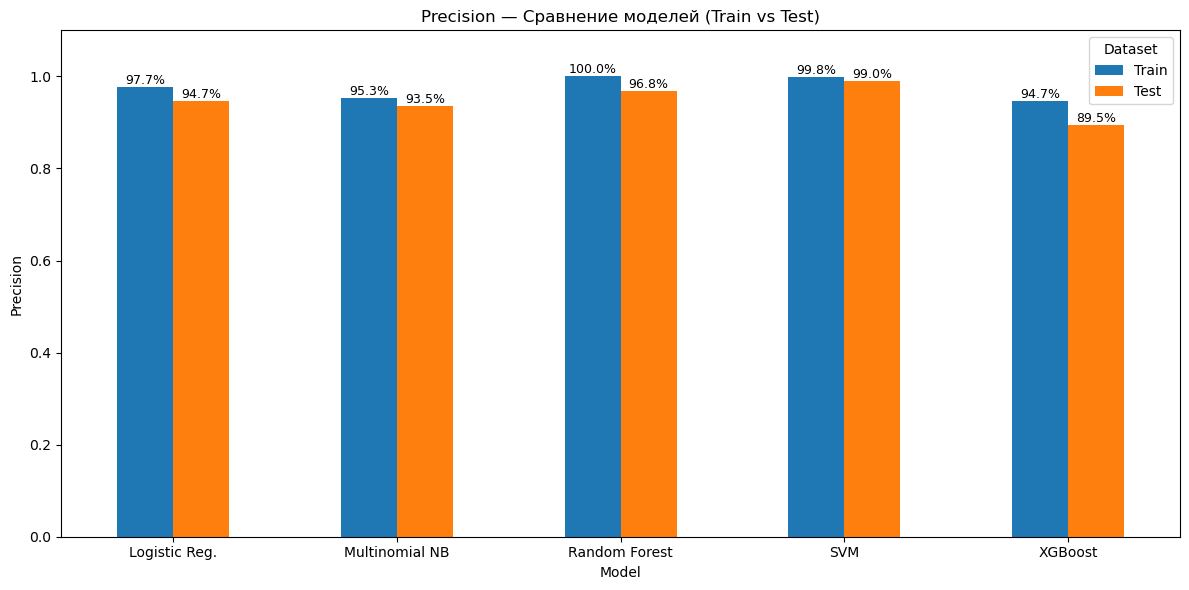

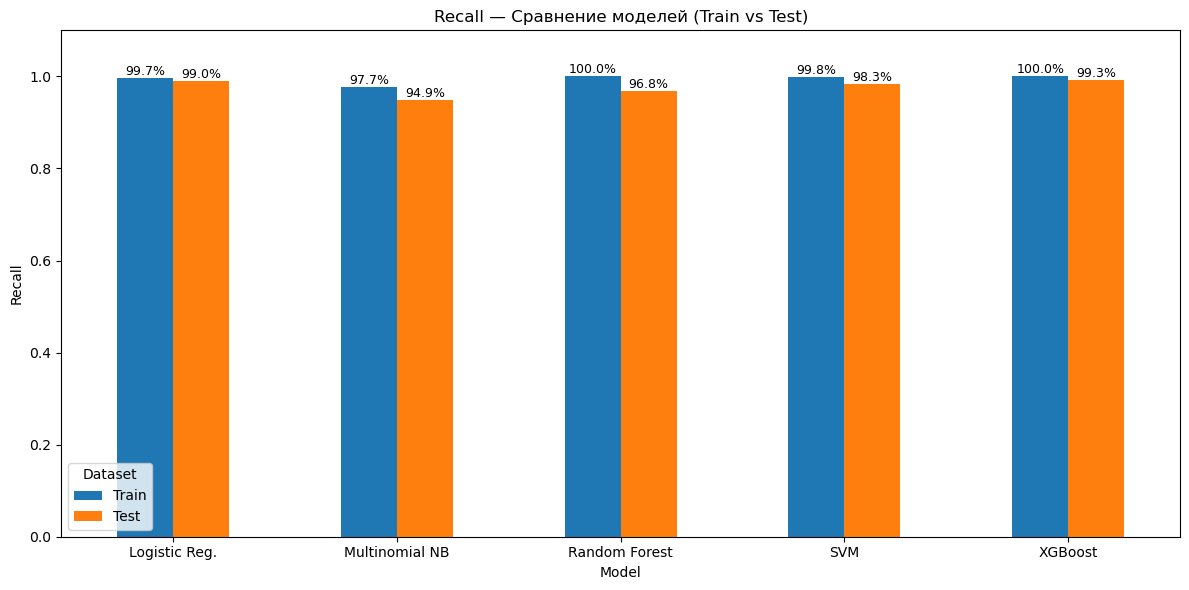

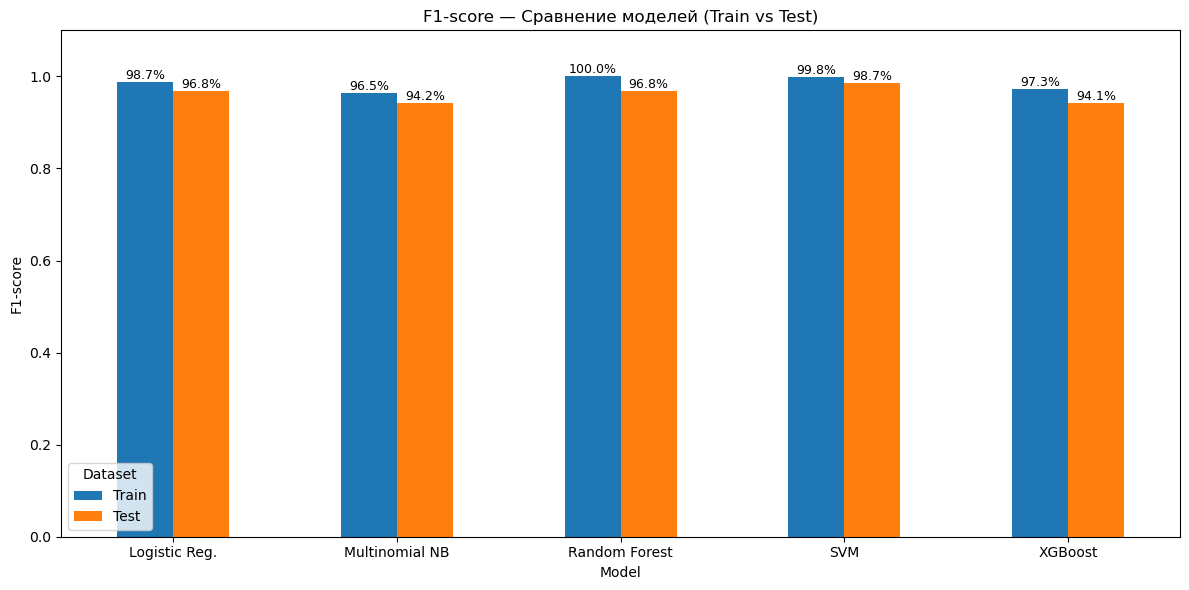

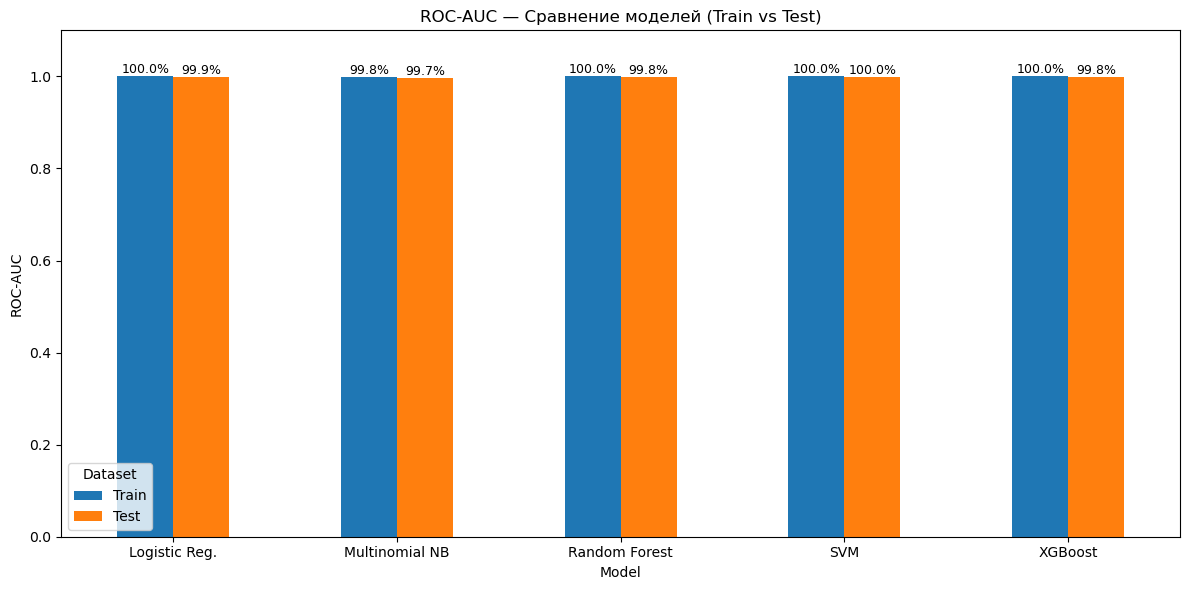

In [148]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

for metric in metrics_list:
    pivot_df = df_metrics.pivot(
        index='Model', columns='Dataset', values=metric
    )[['Train', 'Test']]

    ax = pivot_df.plot(kind='bar', figsize=(12, 6))
    plt.title(f'{metric} — Сравнение моделей (Train vs Test)')
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.ylim(0, 1.1)

    for p in ax.patches:
        v = p.get_height()
        if not np.isnan(v):
            ax.annotate(
                f'{v:.1%}',
                (p.get_x() + p.get_width() / 2, v),
                ha='center', va='bottom', fontsize=9
            )

    plt.tight_layout()
    plt.show()

## Confusion matrix and Classification reports

<Figure size 600x600 with 0 Axes>

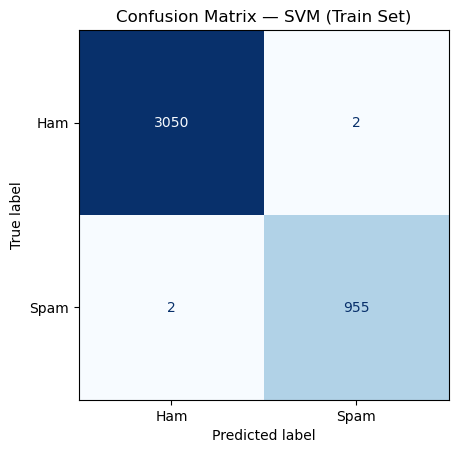

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      3052
        Spam       1.00      1.00      1.00       957

    accuracy                           1.00      4009
   macro avg       1.00      1.00      1.00      4009
weighted avg       1.00      1.00      1.00      4009



<Figure size 600x600 with 0 Axes>

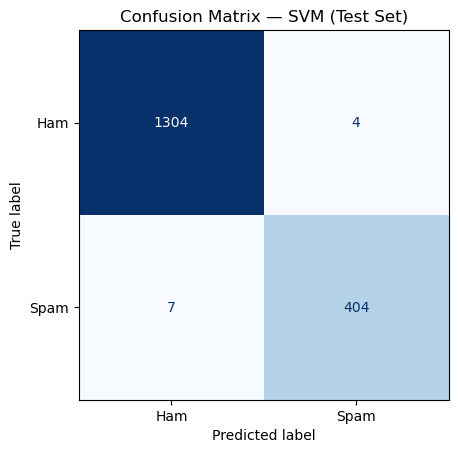

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00      1308
        Spam       0.99      0.98      0.99       411

    accuracy                           0.99      1719
   macro avg       0.99      0.99      0.99      1719
weighted avg       0.99      0.99      0.99      1719



<Figure size 600x600 with 0 Axes>

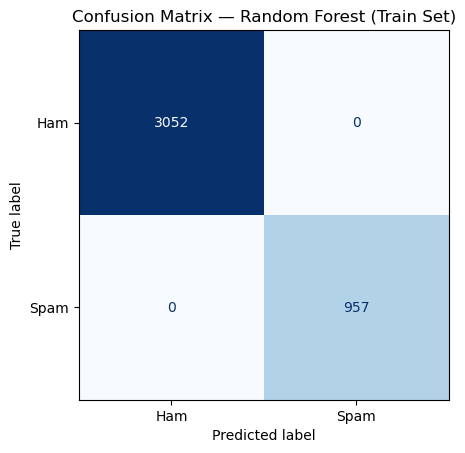

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      3052
        Spam       1.00      1.00      1.00       957

    accuracy                           1.00      4009
   macro avg       1.00      1.00      1.00      4009
weighted avg       1.00      1.00      1.00      4009



<Figure size 600x600 with 0 Axes>

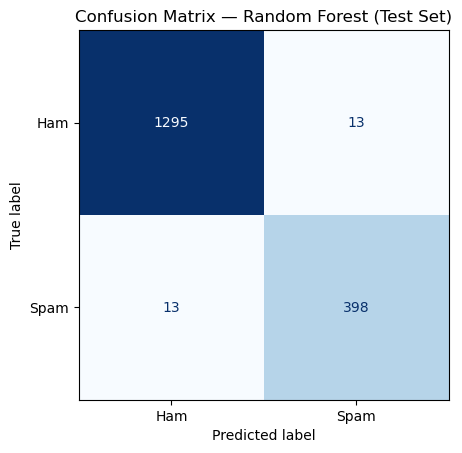

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      1308
        Spam       0.97      0.97      0.97       411

    accuracy                           0.98      1719
   macro avg       0.98      0.98      0.98      1719
weighted avg       0.98      0.98      0.98      1719



<Figure size 600x600 with 0 Axes>

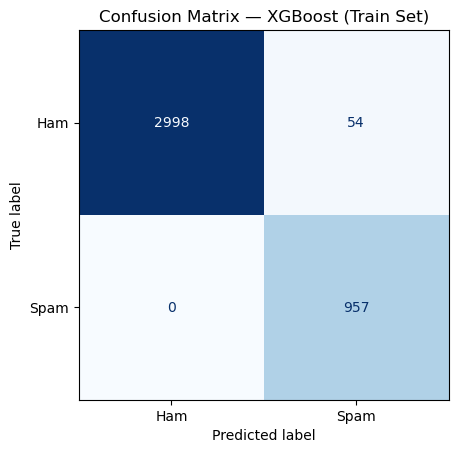

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99      3052
        Spam       0.95      1.00      0.97       957

    accuracy                           0.99      4009
   macro avg       0.97      0.99      0.98      4009
weighted avg       0.99      0.99      0.99      4009



<Figure size 600x600 with 0 Axes>

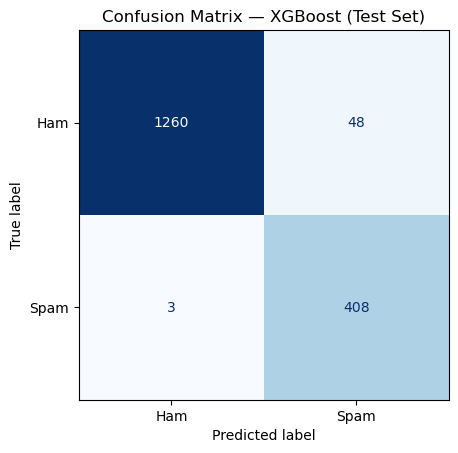

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.96      0.98      1308
        Spam       0.89      0.99      0.94       411

    accuracy                           0.97      1719
   macro avg       0.95      0.98      0.96      1719
weighted avg       0.97      0.97      0.97      1719



<Figure size 600x600 with 0 Axes>

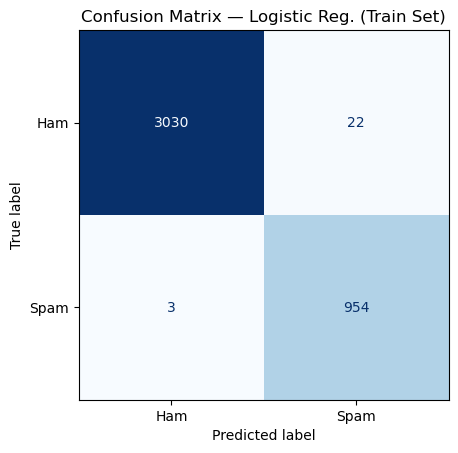

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.99      1.00      3052
        Spam       0.98      1.00      0.99       957

    accuracy                           0.99      4009
   macro avg       0.99      0.99      0.99      4009
weighted avg       0.99      0.99      0.99      4009



<Figure size 600x600 with 0 Axes>

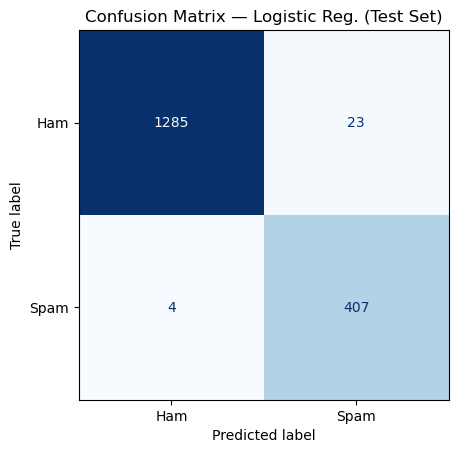

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99      1308
        Spam       0.95      0.99      0.97       411

    accuracy                           0.98      1719
   macro avg       0.97      0.99      0.98      1719
weighted avg       0.98      0.98      0.98      1719



<Figure size 600x600 with 0 Axes>

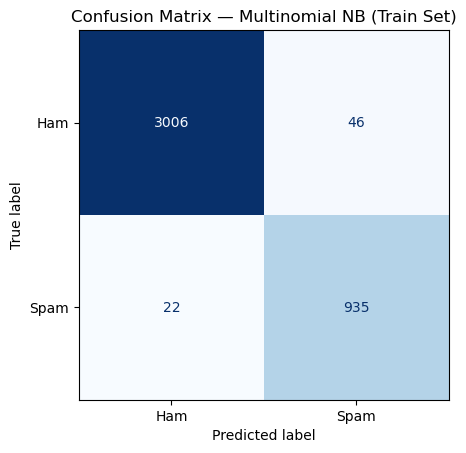

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      3052
        Spam       0.95      0.98      0.96       957

    accuracy                           0.98      4009
   macro avg       0.97      0.98      0.98      4009
weighted avg       0.98      0.98      0.98      4009



<Figure size 600x600 with 0 Axes>

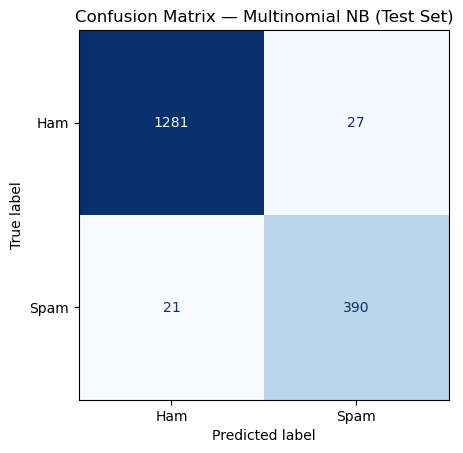

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98      1308
        Spam       0.94      0.95      0.94       411

    accuracy                           0.97      1719
   macro avg       0.96      0.96      0.96      1719
weighted avg       0.97      0.97      0.97      1719



In [149]:
for model_name, model_pipeline in pipelines.items():
    
    # Проход по обучающей и тестовой выборкам
    for dataset_name, (X_data, y_true) in [('Train', (X_train, y_train)), ('Test', (X_test, y_test))]:
        
        y_pred = model_pipeline.predict(X_data)
        
        # confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        
        # Визуализация
        plt.figure(figsize=(6, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
        disp.plot(cmap='Blues', colorbar=False)
        plt.title(f'Confusion Matrix — {model_name} ({dataset_name} Set)')
        plt.show()
        
        # Classification Report 
        print('Classification Report:')
        print(classification_report(
            y_true, y_pred,
            labels=[0, 1],
            target_names=['Ham', 'Spam'],
            zero_division=0  # Чтобы избежать ошибок при делении на 0
        ))

## Общие выводы по работе моделей классификации
### 1. Все модели успешно решают задачу классификации спама
### Все 5 моделей (SVM, Random Forest, XGBoost, Logistic Regression, Naive Bayes) достигли приемлемых или высоких метрик на тестовых данных.

### 2. Лучшие модели по качеству: SVM и XGBoost
### SVM  показывает наилучший баланс Precision, Recall, F1-score
### XGBoost имеет высокий ROC-AUC

### 3. Различия по времени обучения	                     
#### Naive Bayes-Быстро 1.23 сек.
#### Logistic Reg.-Быстро 1.23 сек.
#### Random Forest / XGBoost-Средне 2.76сек./3.64сек.
#### SVC-Самое медленное 7.10 сек.

### Если важна скорость, Naive Bayes или Logistic Regression — лучший выбор.
### Если приоритет — качество, SVM или XGBoost дают максимальные результаты.